

                                      Liverpool John Moores University
                                   Faculty of Engineering and Technology
 
 
               “Neurological Disorders Detection from Speech Emotions Using  Convolutional Neural Network”
 
                                                      By
                                                 Dileep Yadav
 
                                    A final thesis submitted for the degree of
                            MSc Artificial Intelligence (Machine Learning October 2020
 
 
                                               THESIS COMMITTEE
 
                                   Thesis supervisor: Sujith Viswanathan
                           Platform Partner: upGrad Education Private Limited
                     Committee member: A Faculty of Engineering and Technology, LJMU
```



# Memory Information

In [1]:
import psutil
def get_size(bytes, suffix="B"):
    factor = 1024
    for unit in ["", "K", "M", "G", "T", "P"]:
        if bytes < factor:
            return f"{bytes:.2f}{unit}{suffix}"
        bytes /= factor
print("="*40, "Memory Information", "="*40)
svmem = psutil.virtual_memory()
print(f"Total: {get_size(svmem.total)}") ; print(f"Available: {get_size(svmem.available)}")
print(f"Used: {get_size(svmem.used)}") ; print(f"Percentage: {svmem.percent}%")

======================================== Memory Information ========================================
Total: 19.60GB
Available: 18.49GB
Used: 835.37MB
Percentage: 5.7%


# GPU Information

In [23]:
! nvidia-smi

Fri Jan 15 06:38:35 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 390.30                 Driver Version: 390.30                    |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|===============================+======================+======================|
|   0  Tesla K80           Off  | 00000000:00:04.0 Off |                    0 |
| N/A   71C    P0    73W / 149W |  10499MiB / 11441MiB |      0%      Default |
+-------------------------------+----------------------+----------------------+
                                                                               
+-----------------------------------------------------------------------------+
| Processes:                                                       GPU Memory |
|  GPU  

## **Getting started**

In [33]:
import scipy.io as sio
import argparse
import os
import sys
import numpy as np
import pandas as pd
import time
import pickle

In [34]:
np.random.seed(0)

In [35]:
def data_1Dto2D(data, Y=9, X=9):
    data_2D = np.zeros([Y, X])
    data_2D[0] = (0,  	   	0, 	        0,          data[0],    0,          data[16], 	0,  	    0, 	        0       )
    data_2D[1] = (0,  	   	0,          0,          data[1],    0,          data[17],   0,          0,          0       )
    data_2D[2] = (data[3],  0,          data[2],    0,          data[18],   0,          data[19],   0,          data[20])
    data_2D[3] = (0,        data[4],    0,          data[5],    0,          data[22],   0,          data[21],   0       )
    data_2D[4] = (data[7],  0,          data[6],    0,          data[23],   0,          data[24],   0,          data[25])
    data_2D[5] = (0,        data[8],    0,          data[9],    0,          data[27],   0,          data[26],   0       )
    data_2D[6] = (data[11], 0,          data[10],   0,          data[15],   0,          data[28],   0,          data[29])
    data_2D[7] = (0,        0,          0,          data[12],   0,          data[30],   0,          0,          0       )
    data_2D[8] = (0,        0,          0,          data[13],   data[14],   data[31],   0,          0,          0       )
    # return shape:9*9
    return data_2D

In [36]:
def norm_dataset(dataset_1D):
    norm_dataset_1D = np.zeros([dataset_1D.shape[0], 32])
    for i in range(dataset_1D.shape[0]):
        norm_dataset_1D[i] = feature_normalize(dataset_1D[i])
    # return shape: m*32
    return norm_dataset_1D

In [37]:
def feature_normalize(data):
    mean = data[data.nonzero()].mean()
    sigma = data[data. nonzero ()].std()
    data_normalized = data
    data_normalized[data_normalized.nonzero()] = (data_normalized[data_normalized.nonzero()] - mean)/sigma
    # return shape: 9*9
    return data_normalized

In [38]:
def dataset_1Dto2D(dataset_1D):
    dataset_2D = np.zeros([dataset_1D.shape[0],9,9])
    for i in range(dataset_1D.shape[0]):
        dataset_2D[i] = data_1Dto2D(dataset_1D[i])
    # return shape: m*9*9
    return dataset_2D

In [39]:
def norm_dataset_1Dto2D(dataset_1D):
    norm_dataset_2D = np.zeros([dataset_1D.shape[0], 9, 9])
    for i in range(dataset_1D.shape[0]):
        norm_dataset_2D[i] = feature_normalize( data_1Dto2D(dataset_1D[i]))
    # return shape: m*9*9
    return norm_dataset_2D

In [40]:
def windows(data, size):
    start = 0
    while ((start+size) < data.shape[0]):
        yield int(start), int(start + size)
        start += size

In [41]:
def segment_signal_without_transition(data,label,label_index,window_size):
    # get data file name and label file name
    for (start, end) in windows(data, window_size):
        # print(data.shape)
        if((len(data[start:end]) == window_size)):
            if(start == 0):
                segments = data[start:end]
                segments = np.vstack([segments, data[start:end]])

                labels = np.array(label[label_index])
                labels = np.append(labels, np.array(label[label_index]))
            else:
                segments = np.vstack([segments, data[start:end]])
                labels = np.append(labels, np.array(label[label_index])) # labels = np.append(labels, stats.mode(label[start:end])[0][0])
    return segments, labels

In [42]:
def apply_mixup(dataset_file,window_size,label,yes_or_not): # initial empty label arrays
   # %debug 
    print("Processing",dataset_file,"..........")
    data_file_in = sio.loadmat(dataset_file)
    data_in = data_file_in["data"].transpose(0,2,1)
    #0 valence, 1 arousal, 2 dominance, 3 liking
    lab=0
    if label=="arousal":
        lab=1
    elif label=="valence":
        lab=0 
    label_in= data_file_in["labels"][:,lab]>5
    label_inter	= np.empty([0]) # initial empty data arrays
    data_inter_cnn	= np.empty([0,window_size, 9, 9])
    data_inter_rnn	= np.empty([0, window_size, 32])
    trials = data_in.shape[0]

    # Data pre-processing
    for trial in range(0,trials):
        if yes_or_not=="yes":
            base_signal = (data_in[trial,0:128,0:32]+data_in[trial,128:256,0:32]+data_in[trial,256:384,0:32])/3
        else:
            base_signal = 0
        data = data_in[trial,384:8064,0:32]
        # compute the deviation between baseline signals and experimental signals
        for i in range(0,60):
            data[i*128:(i+1)*128,0:32]=data[i*128:(i+1)*128,0:32]-base_signal
        label_index = trial
        #read data and label
        data = norm_dataset(data)
        data, label = segment_signal_without_transition(data, label_in,label_index,window_size)
        # cnn data process
        data_cnn    = dataset_1Dto2D(data)
        data_cnn    = data_cnn.reshape ( int(data_cnn.shape[0]/window_size), window_size, 9, 9)
        # rnn data process
        data_rnn    = data. reshape(int(data.shape[0]/window_size), window_size, 32)
        # append new data and label
        data_inter_cnn  = np.vstack([data_inter_cnn, data_cnn])
        data_inter_rnn  = np.vstack([data_inter_rnn, data_rnn])
        label_inter = np.append(label_inter, label)
    '''
    print("total cnn size:", data_inter_cnn.shape)
    print("total rnn size:", data_inter_rnn.shape)
    print("total label size:", label_inter.shape)
    '''
    # shuffle data
    index = np.array(range(0, len(label_inter)))
    np.random.shuffle( index)
    shuffled_data_cnn	= data_inter_cnn[index]
    shuffled_data_rnn	= data_inter_rnn[index]
    shuffled_label 	= label_inter[index]
    return shuffled_data_cnn ,shuffled_data_rnn,shuffled_label,record

In [43]:
# from google.colab import drive
# drive.mount('/content/gdrive/')

In [44]:
# import sys
# sys.path.append('/content/gdrive/My Drive/Colab Notebooks/LJMU_PROJECT/data_preprocessed_matlab/')

In [45]:
# %cd /content/gdrive/My Drive/Colab Notebooks/LJMU_PROJECT/data_preprocessed_matlab/
  
# !pwd

In [46]:
 #sys.argv[1]     # arousal/valence
 #sys.argv[2]     # yes/no (using baseline signals or not)
sys.argv.clear()
sys.argv.insert(0, "")
#sys.argv.insert(1, "arousal")
#sys.argv.insert(2, "yes")
#sys.argv.insert(2, "no")

sys.argv.insert(1, "valence")
#sys.argv.insert(2, "yes")
sys.argv.insert(2, "no")

In [47]:
sys.argv

['', 'valence', 'no']

In [48]:
begin = time.time()
print("time begin:",time.localtime())
dataset_dir		=   "/mnt/disks/user/project/data_preprocessed_matlab/"
window_size		=	128
output_dir		=   "/mnt/disks/user/project/deap_shuffled_data/"
    
label_class     =   sys.argv[1]     # arousal/valence
suffix          =   sys.argv[2]     # yes/no (using baseline signals or not)
    # get directory name for one subject
record_list = [task for task in os.listdir(dataset_dir) if os.path.isfile(os.path.join(dataset_dir,task))]
output_dir = output_dir+suffix+"_"+label_class+"/"
if os.path.isdir(output_dir)==False:
        os.makedirs(output_dir)
        print(record_list)

for record in record_list:
        file = os.path.join(dataset_dir,record)
        print("" )
        print("" )
        print("::::::---->Processing for File:", file[-8:] )
        print("", )
        shuffled_cnn_data,shuffled_rnn_data,shuffled_label,record = apply_mixup(file, window_size,label_class,suffix)
        output_data_cnn = output_dir+record+"_win_"+str(window_size)+"_cnn_dataset.pkl"
        output_data_rnn = output_dir+record+"_win_"+str(window_size)+"_rnn_dataset.pkl"
        output_label= output_dir+record+"_win_"+str(window_size)+"_labels.pkl"

        with open(output_data_cnn, "wb") as fp:
            pickle.dump( shuffled_cnn_data,fp, protocol=4)
        with open( output_data_rnn, "wb") as fp:
            pickle.dump(shuffled_rnn_data, fp, protocol=4)
        with open(output_label, "wb") as fp:
            pickle.dump(shuffled_label, fp)
        end = time.time()

        
        print("end time:",time.localtime())
        print("time consuming:",(end-begin))
        
        # break

time begin: time.struct_time(tm_year=2021, tm_mon=2, tm_mday=13, tm_hour=8, tm_min=22, tm_sec=21, tm_wday=5, tm_yday=44, tm_isdst=0)


::::::---->Processing for File: /s11.mat

Processing /mnt/disks/user/project/data_preprocessed_matlab/s11.mat ..........
end time: time.struct_time(tm_year=2021, tm_mon=2, tm_mday=13, tm_hour=8, tm_min=22, tm_sec=45, tm_wday=5, tm_yday=44, tm_isdst=0)
time consuming: 24.31942129135132


::::::---->Processing for File: /s32.mat

Processing /mnt/disks/user/project/data_preprocessed_matlab/s32.mat ..........
end time: time.struct_time(tm_year=2021, tm_mon=2, tm_mday=13, tm_hour=8, tm_min=23, tm_sec=10, tm_wday=5, tm_yday=44, tm_isdst=0)
time consuming: 49.18601655960083


::::::---->Processing for File: /s18.mat

Processing /mnt/disks/user/project/data_preprocessed_matlab/s18.mat ..........
end time: time.struct_time(tm_year=2021, tm_mon=2, tm_mday=13, tm_hour=8, tm_min=23, tm_sec=34, tm_wday=5, tm_yday=44, tm_isdst=0)
time consuming: 73.51252126693726


:

end time: time.struct_time(tm_year=2021, tm_mon=2, tm_mday=13, tm_hour=8, tm_min=33, tm_sec=59, tm_wday=5, tm_yday=44, tm_isdst=0)
time consuming: 697.9351983070374


::::::---->Processing for File: /s15.mat

Processing /mnt/disks/user/project/data_preprocessed_matlab/s15.mat ..........
end time: time.struct_time(tm_year=2021, tm_mon=2, tm_mday=13, tm_hour=8, tm_min=34, tm_sec=23, tm_wday=5, tm_yday=44, tm_isdst=0)
time consuming: 722.2870242595673


::::::---->Processing for File: /s03.mat

Processing /mnt/disks/user/project/data_preprocessed_matlab/s03.mat ..........
end time: time.struct_time(tm_year=2021, tm_mon=2, tm_mday=13, tm_hour=8, tm_min=34, tm_sec=48, tm_wday=5, tm_yday=44, tm_isdst=0)
time consuming: 746.7381083965302


::::::---->Processing for File: /s22.mat

Processing /mnt/disks/user/project/data_preprocessed_matlab/s22.mat ..........
end time: time.struct_time(tm_year=2021, tm_mon=2, tm_mday=13, tm_hour=8, tm_min=35, tm_sec=12, tm_wday=5, tm_yday=44, tm_isdst=0)
time 

### **`Train The model`**

In [13]:
import sys
import sklearn
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import os
import pandas as pd
import pickle
import tensorflow as tf
import numpy as np
import time
import math
import scipy.io as sio

In [14]:
#sys.argv[1]     # arousal/valence
#sys.argv[2]     # yes/no (using baseline signals or not)
sys.argv.clear()
sys.argv.insert(0, "s02")
#sys.argv.insert(1, "arousal")
#sys.argv.insert(2, "yes")
#sys.argv.insert(2, "no")
 
sys.argv.insert(1, "valence")
#sys.argv.insert(2, "yes")
sys.argv.insert(2, "no")

In [15]:
sys.argv

['s02', 'valence', 'no']

In [16]:
#pip install tensorflow==1.4.0
tf.reset_default_graph()

In [ ]:
final_fuse = "concat"
 
conv_1_shape = '4*4*32'
pool_1_shape = 'None'
 
conv_2_shape = '4*4*64'
pool_2_shape = 'None'
 
conv_3_shape = '4*4*128'
pool_3_shape = 'None'
 
conv_4_shape = '1*1*13'
pool_4_shape = 'None'
 
window_size = 128
n_lstm_layers = 2
# lstm full connected parameter

n_hidden_state = 32
print("\nsize of hidden state", n_hidden_state)
n_fc_out = 1024
n_fc_in = 1024
 
dropout_prob = 0.5
np.random.seed(32)
 
norm_type = '2D'
regularization_method = 'dropout'
enable_penalty = True
 
cnn_suffix        =".mat_win_128_cnn_dataset.pkl"
rnn_suffix        =".mat_win_128_rnn_dataset.pkl"
label_suffix    =".mat_win_128_labels.pkl"
 
data_file    =sys.argv[0]
arousal_or_valence = sys.argv[1]
with_or_without = sys.argv[2]
 
dataset_dir = "/mnt/disks/user/project/deap_shuffled_data/"+with_or_without+"_"+arousal_or_valence+"/"
###load training set
with open(dataset_dir + data_file + cnn_suffix, "rb") as fp:
    cnn_datasets = pickle.load(fp)
with open(dataset_dir + data_file + rnn_suffix, "rb") as fp:
    rnn_datasets = pickle.load(fp)
with open(dataset_dir + data_file + label_suffix, "rb") as fp:
    labels = pickle.load(fp)
    labels = np.transpose(labels)
    print("loaded shape:",labels.shape)
lables_backup = labels
print("cnn_dataset shape before reshape:", np.shape(cnn_datasets))
cnn_datasets = cnn_datasets.reshape(len(cnn_datasets), window_size, 9,9, 1)
print("cnn_dataset shape after reshape:", np.shape(cnn_datasets))
one_hot_labels = np.array(list(pd.get_dummies(labels)))
 
labels = np.asarray(pd.get_dummies(labels), dtype=np.int8)
 
# shuffle data
index = np.array(range(0, len(labels)))
np.random.shuffle(index)
 
cnn_datasets   = cnn_datasets[index]
rnn_datasets   = rnn_datasets[index]
labels  = labels[index]
 
print("========(" + time.asctime(time.localtime(time.time())) + ") Load and Split dataset End =================\n")
print("========(" + time.asctime(time.localtime(time.time())) + ") Define parameters and functions Begin: =====\n")
 
# input parameter
n_input_ele = 32
n_time_step = window_size
 
input_channel_num = 1
input_height = 9
input_width = 9
 
n_labels = 2
# training parameter
lambda_loss_amount = 0.5
training_epochs = 80
 
batch_size = 280
 
 
# kernel parameter
kernel_height_1st = 4
kernel_width_1st = 4
 
kernel_height_2nd = 4
kernel_width_2nd = 4
 
kernel_height_3rd = 4
kernel_width_3rd = 4
 
kernel_height_4th = 1
kernel_width_4th = 1
 
kernel_stride = 1
conv_channel_num = 32
 
# algorithn parameter
learning_rate = 1e-4
 
def weight_variable(shape):
    initial = tf.truncated_normal(shape, stddev=0.1)
    return tf.Variable(initial)
 
def bias_variable(shape):
    initial = tf.constant(0.1, shape=shape)
    return tf.Variable(initial)
 
def conv2d(x, W, kernel_stride):
    # API: must strides[0]=strides[4]=1
    return tf.nn.conv2d(x, W, strides=[1, kernel_stride, kernel_stride, 1], padding='SAME')
 
def apply_conv2d(x, filter_height, filter_width, in_channels, out_channels, kernel_stride):
    weight = weight_variable([filter_height, filter_width, in_channels, out_channels])
    bias = bias_variable([out_channels])  # each feature map shares the same weight and bias
    print("weight shape:", np.shape(weight))
    print("x shape:", np.shape(x))
    #tf.layers.batch_normalization()
    return tf.nn.elu(tf.layers.batch_normalization(conv2d(x, weight, kernel_stride)))
 
def apply_max_pooling(x, pooling_height, pooling_width, pooling_stride):
    # API: must ksize[0]=ksize[4]=1, strides[0]=strides[4]=1
    return tf.nn.max_pool(x, ksize=[1, pooling_height, pooling_width, 1],
                          strides=[1, pooling_stride, pooling_stride, 1], padding='SAME')
 
def apply_fully_connect(x, x_size, fc_size):
    fc_weight = weight_variable([x_size, fc_size])
    fc_bias = bias_variable([fc_size])
    return tf.nn.elu(tf.add(tf.matmul(x, fc_weight), fc_bias))
 
def apply_readout(x, x_size, readout_size):
    readout_weight = weight_variable([x_size, readout_size])
    readout_bias = bias_variable([readout_size])
    return tf.add(tf.matmul(x, readout_weight), readout_bias)
 
print("\n=============(" + time.asctime(time.localtime(time.time())) + ") Define parameters and functions End =======")
print("\n=============(" + time.asctime(time.localtime(time.time())) + ") Define NN structure Begin: ================")
 
# input placeholder
cnn_in = tf.placeholder(tf.float32, shape=[None, input_height, input_width, input_channel_num], name='cnn_in')
rnn_in = tf.placeholder(tf.float32, shape=[None, n_time_step, n_input_ele], name='rnn_in')
Y = tf.placeholder(tf.float32, shape=[None, n_labels], name='Y')
keep_prob = tf.placeholder(tf.float32, name='keep_prob')
phase_train = tf.placeholder(tf.bool, name='phase_train')
 
###########################################################################################
# add cnn parallel to network
###########################################################################################
# first CNN layer
with tf.name_scope("conv_1"):
    conv_1 = apply_conv2d(cnn_in, kernel_height_1st, kernel_width_1st, input_channel_num, conv_channel_num, kernel_stride)
    print("conv_1 shape:", conv_1.shape)
# second CNN layer
with tf.name_scope("conv_2"):
    conv_2 = apply_conv2d(conv_1, kernel_height_2nd, kernel_width_2nd, conv_channel_num, conv_channel_num * 2,kernel_stride)
    print("conv_2 shape:", conv_2.shape)
# third CNN layer
with tf.name_scope("conv_3"):
    conv_3 = apply_conv2d(conv_2, kernel_height_3rd, kernel_width_3rd, conv_channel_num * 2, conv_channel_num * 4,kernel_stride)
    print("conv_3 shape:", conv_3.shape)
# depth concatenate
with tf.name_scope("depth_concatenate"):
    cube = tf.reshape(conv_3,[-1,9,9,conv_channel_num * 4 * window_size])
    print("cube shape:", cube.shape)
# fourth CNN layer
with tf.name_scope("conv_4"):
    conv_4 = apply_conv2d(cube, kernel_height_4th, kernel_width_4th, conv_channel_num * 4 * window_size, 13,kernel_stride)
    print("\nconv_4 shape:", conv_4.shape)
 
# flatten (13*9*9) cube into a 1053 vector.
shape = conv_4.get_shape().as_list()
conv_3_flat = tf.reshape(conv_4, [-1, shape[1] * shape[2] * shape[3]])
 
cnn_out_fuse = conv_3_flat
###########################################################################################
# add lstm parallel to network
###########################################################################################
# rnn_in         ==>    [batch_size, n_time_step, n_electrode]
shape = rnn_in.get_shape().as_list()
# rnn_in_flat     ==>    [batch_size*n_time_step, n_electrode]
rnn_in_flat = tf.reshape(rnn_in, [-1, shape[2]])
# fc_in     ==>    [batch_size*n_time_step, n_electrode]
rnn_fc_in = apply_fully_connect(rnn_in_flat, shape[2], n_fc_in)
# lstm_in    ==>    [batch_size, n_time_step, n_fc_in]
lstm_in = tf.reshape(rnn_fc_in, [-1, n_time_step, n_fc_in])
# define lstm cell
cells = []
for _ in range(n_lstm_layers):
    with tf.name_scope("LSTM_"+str(n_lstm_layers)):
        cell = tf.contrib.rnn.BasicLSTMCell(n_hidden_state, forget_bias=1.0, state_is_tuple=True)
        cell = tf.contrib.rnn.DropoutWrapper(cell, output_keep_prob=keep_prob)
        cells.append(cell)
lstm_cell = tf.contrib.rnn.MultiRNNCell(cells)
 
output, states = tf.nn.dynamic_rnn(lstm_cell, lstm_in,dtype=tf.float32, time_major=False)
 
output = tf.unstack(tf.transpose(output, [1, 0, 2]), name='lstm_out')
rnn_output = output[-1]
###########################################################################################
# fully connected
###########################################################################################
# rnn_output ==> [batch, fc_size]
shape_rnn_out = rnn_output.get_shape().as_list()
# fc_out ==> [batch_size, n_fc_out]
lstm_fc_out = apply_fully_connect(rnn_output, shape_rnn_out[1], n_fc_out)
# keep_prob = tf.placeholder(tf.float32)
lstm_fc_drop = tf.nn.dropout(lstm_fc_out, keep_prob)
###########################################################################################
# fuse parallel cnn and lstm
###########################################################################################
print("final fuse method: concat")
fuse_cnn_rnn = tf.concat([cnn_out_fuse, lstm_fc_drop], axis=1)
 
fuse_cnn_rnn_shape = fuse_cnn_rnn.get_shape().as_list()
print("\nfuse_cnn_rnn:", fuse_cnn_rnn_shape)
# readout layer
y_ = apply_readout(fuse_cnn_rnn, fuse_cnn_rnn_shape[1], n_labels)
y_pred = tf.argmax(tf.nn.softmax(y_), 1, name="y_pred")
y_posi = tf.nn.softmax(y_, name="y_posi")
 
# l2 regularization
l2 = lambda_loss_amount * sum(
    tf.nn.l2_loss(tf_var) for tf_var in tf.trainable_variables()
)
 
if enable_penalty:
    # cross entropy cost function
    cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=y_, labels=Y) + l2, name='loss')
    tf.summary.scalar('cost_with_L2',cost)
else:
    # cross entropy cost function
    cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=y_, labels=Y), name='loss')
    tf.summary.scalar('cost',cost)
 
optimizer = tf.train.AdamOptimizer(learning_rate).minimize(cost)
 
# get correctly predicted object and accuracy
correct_prediction = tf.equal(tf.argmax(tf.nn.softmax(y_), 1), tf.argmax(Y, 1))
accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32), name='accuracy')
tf.summary.scalar('accuracy',accuracy)
 
print("\n==========(" + time.asctime(time.localtime(time.time())) + ") Define NN structure End ===========")
 
print("\n==========(" + time.asctime(time.localtime(time.time())) + ") Train and Test NN Begin:===========")
 
config = tf.ConfigProto()
# config.gpu_options.allow_growth = True
config.gpu_options.per_process_gpu_memory_fraction = 0.9
 
merged = tf.summary.merge_all()
logdir = "Dileep_Tensorboard"
train_writer = tf.summary.FileWriter("log/"+logdir+"/train")
test_writer = tf.summary.FileWriter("log/"+logdir+"/test")
 
fold = 3
print("Total Cross fold:",fold)
for curr_fold in range(fold):
    print("======================= Running Cross fold:: ",curr_fold,":: ===============================")
    fold_size = cnn_datasets.shape[0]//fold
    indexes_list = [i for i in range(len(cnn_datasets))]
    indexes = np.array(indexes_list)
    split_list = [i for i in range(curr_fold*fold_size,(curr_fold+1)*fold_size)]
    split = np.array(split_list)
    cnn_test_x = cnn_datasets[split] 
    test_y = labels[split]
    rnn_test_x = rnn_datasets[split]
 
    split = np.array(list(set(indexes_list)^set(split_list)))
    cnn_train_x = cnn_datasets[split]
    rnn_train_x = rnn_datasets[split]
    train_y = labels[split]
    train_sample = train_y.shape[0]
    print("Training Sample:", train_sample)
    test_sample = test_y.shape[0]
    print("Test Sample    :",test_sample)
    # set train batch number per epoch
    batch_num_per_epoch = math.floor(cnn_train_x.shape[0]/batch_size)+ 1
 
    # set test batch number per epoch
    accuracy_batch_size = batch_size
    train_accuracy_batch_num = batch_num_per_epoch
    test_accuracy_batch_num = math.floor(cnn_test_x.shape[0]/batch_size)+ 1
 
    # print label
    one_hot_labels = np.array(list(pd.get_dummies(lables_backup)))
    print(one_hot_labels)
 
    with tf.Session(config=config) as session:
        train_writer.add_graph(session.graph)
        count_cost = 0
        train_count_accuracy = 0
        test_count_accuracy = 0
 
        session.run(tf.global_variables_initializer())
        train_accuracy_save = np.zeros(shape=[0], dtype=float)
        test_accuracy_save = np.zeros(shape=[0], dtype=float)
        test_loss_save = np.zeros(shape=[0], dtype=float)
        train_loss_save = np.zeros(shape=[0], dtype=float)
        for epoch in range(training_epochs):
            print("learning rate: ",learning_rate)
            cost_history = np.zeros(shape=[0], dtype=float)
            for b in range(batch_num_per_epoch):
                start = b* batch_size
                if (b+1)*batch_size>train_y.shape[0]:
                    offset = train_y.shape[0] % batch_size
                else:
                    offset = batch_size
                print("start:",start,"end:",start+offset)
                cnn_batch = cnn_train_x[start:(start + offset), :, :, :, :]
                cnn_batch = cnn_batch.reshape(len(cnn_batch) * window_size, 9, 9, 1)
                rnn_batch = rnn_train_x[start:(start + offset), :, :]
                batch_y = train_y[start:(start + offset), :]
                _ , c = session.run([optimizer, cost],
                                   feed_dict={cnn_in: cnn_batch, rnn_in: rnn_batch, Y: batch_y, keep_prob: 1 - dropout_prob,
                                              phase_train: True})
                cost_history = np.append(cost_history, c)
                count_cost += 1
            if (epoch % 1 == 0):
                train_accuracy = np.zeros(shape=[0], dtype=float)
                test_accuracy = np.zeros(shape=[0], dtype=float)
                test_loss = np.zeros(shape=[0], dtype=float)
                train_loss = np.zeros(shape=[0], dtype=float)
 
                for i in range(train_accuracy_batch_num):
                    start = i* batch_size
                    if (i+1)*batch_size>train_y.shape[0]:
                        offset = train_y.shape[0] % batch_size
                    else:
                        offset = batch_size
                    train_cnn_batch = cnn_train_x[start:(start + offset), :, :, :, :]
                    train_cnn_batch = train_cnn_batch.reshape(len(train_cnn_batch) * window_size, 9, 9, 1)
 
                    train_rnn_batch = rnn_train_x[start:(start + offset), :, :]
                    train_batch_y = train_y[start:(start + offset), :]
 
                    tf_summary,train_a, train_c = session.run([merged,accuracy, cost],
                                                   feed_dict={cnn_in: train_cnn_batch, rnn_in: train_rnn_batch,
                                                              Y: train_batch_y, keep_prob: 1.0, phase_train: False})
                    train_writer.add_summary(tf_summary,train_count_accuracy)
                    train_loss = np.append(train_loss, train_c)
                    train_accuracy = np.append(train_accuracy, train_a)
                    train_count_accuracy += 1
                print("(" + time.asctime(time.localtime(time.time())) + ") Epoch: ", epoch + 1, " Training Cost: ",
                      np.mean(train_loss), "Training Accuracy: ", np.mean(train_accuracy))
                train_accuracy_save = np.append(train_accuracy_save, np.mean(train_accuracy))
                train_loss_save = np.append(train_loss_save, np.mean(train_loss))
 
                if(np.mean(train_accuracy)<0.8):
                    learning_rate=1e-4
                elif(0.8<np.mean(train_accuracy)<0.85):
                    learning_rate=5e-5
                elif(0.85<np.mean(train_accuracy)):
                    learning_rate=5e-6
 
                for j in range(test_accuracy_batch_num):
                    start = j * batch_size
                    # print(start)
                    if (j+1)*batch_size>test_y.shape[0]:
                        offset = test_y.shape[0] % batch_size
                    else:
                        offset = batch_size
                    test_cnn_batch = cnn_test_x[start:(start + offset), :, :, :, :]
                    test_cnn_batch = test_cnn_batch.reshape(len(test_cnn_batch) * window_size, 9, 9, 1)
 
                    test_rnn_batch = rnn_test_x[start:(start + offset), :, :]
                    test_batch_y = test_y[start:(start + offset), :]
 
                    tf_test_summary,test_a, test_c = session.run([merged,accuracy, cost],
                                                 feed_dict={cnn_in: test_cnn_batch, rnn_in: test_rnn_batch, Y: test_batch_y,
                                                            keep_prob: 1.0, phase_train: False})
                    test_writer.add_summary(tf_test_summary,test_count_accuracy)
                    test_accuracy = np.append(test_accuracy, test_a)
                    test_loss = np.append(test_loss, test_c)
                    test_count_accuracy += 1 
                print("(" + time.asctime(time.localtime(time.time())) + ") Epoch: ", epoch + 1, " Test Cost: ",
                      np.mean(test_loss), "Test Accuracy: ", np.mean(test_accuracy), "\n")
                test_accuracy_save = np.append(test_accuracy_save, np.mean(test_accuracy))
                test_loss_save = np.append(test_loss_save, np.mean(test_loss))
            # reshuffle
            index = np.array(range(0, len(train_y)))
            np.random.shuffle(index)
            cnn_train_x=cnn_train_x[index]
            rnn_train_x=rnn_train_x[index]
            train_y=train_y[index]
 
            # learning_rate decay
            if(np.mean(train_accuracy)<0.9):
                learning_rate=1e-4
            elif(0.9<np.mean(train_accuracy)<0.95):
                learning_rate=5e-5
            elif(0.99<np.mean(train_accuracy)):
                learning_rate=5e-6
 
        test_accuracy = np.zeros(shape=[0], dtype=float)
        test_loss = np.zeros(shape=[0], dtype=float)
        test_pred = np.zeros(shape=[0], dtype=float)
        test_true = np.zeros(shape=[0, 2], dtype=float)
        test_posi = np.zeros(shape=[0, 2], dtype=float)
        for k in range(test_accuracy_batch_num):
            start = k * batch_size
            if (k+1)*batch_size>test_y.shape[0]:
                offset = test_y.shape[0] % batch_size
            else:
                offset = batch_size
            test_cnn_batch = cnn_test_x[start:(start + offset), :, :, :, :]
            test_cnn_batch = test_cnn_batch.reshape(len(test_cnn_batch) * window_size, 9, 9, 1)
            test_rnn_batch = rnn_test_x[start:(start + offset), :, :]
            test_batch_y = test_y[start:(start + offset), :]
 
            test_a, test_c, test_p, test_r = session.run([accuracy, cost, y_pred, y_posi],
                                                         feed_dict={cnn_in: test_cnn_batch, rnn_in: test_rnn_batch,
                                                                    Y: test_batch_y, keep_prob: 1.0, phase_train: False})
            test_t = test_batch_y
 
            test_accuracy = np.append(test_accuracy, test_a)
            test_loss = np.append(test_loss, test_c)
            test_pred = np.append(test_pred, test_p)
            test_true = np.vstack([test_true, test_t])
            test_posi = np.vstack([test_posi, test_r])
        test_pred_1_hot = np.asarray(pd.get_dummies(test_pred), dtype=np.int8)
        test_true_list = tf.argmax(test_true, 1).eval()
        # recall
        test_recall = recall_score(test_true, test_pred_1_hot, average=None)
        # precision
        test_precision = precision_score(test_true, test_pred_1_hot, average=None)
        # f1 score
        test_f1 = f1_score(test_true, test_pred_1_hot, average=None)
        # confusion matrix
        # confusion_matrix = confusion_matrix(test_true_list, test_pred)
        print(":::::::-------------------recall:", test_recall)
        print(":::::::----------------precision:", test_precision)
        print(":::::::-----------------f1_score:", test_f1)
        # print("**********confusion_matrix:\n", confusion_matrix)
 
        print("(" + time.asctime(time.localtime(time.time())) + ") Final Test Cost: ", np.mean(test_loss),
              "Final Test Accuracy: ", np.mean(test_accuracy))
 
        result = pd.DataFrame(
            {'epoch': range(1, epoch + 2), "train_accuracy": train_accuracy_save, "test_accuracy": test_accuracy_save,
             "train_loss": train_loss_save, "test_loss": test_loss_save})
 
        ins = pd.DataFrame({'conv_1': conv_1_shape,'conv_2': conv_2_shape,'conv_3': conv_3_shape, 'conv_4': conv_4_shape,
                            'final_fuse': final_fuse,'rnn fc in': n_fc_in, 'rnn fc out': n_fc_out,
                            'hidden_size': n_hidden_state, 'accuracy': np.mean(test_accuracy),
                            'keep_prob': 1 - dropout_prob,'sliding_window': window_size, "epoch": epoch + 1, "norm": norm_type,
                            "learning_rate": learning_rate, "regularization": regularization_method,
                            "train_sample": train_sample, "test_sample": test_sample,"batch_size":batch_size}, index=[0])
        summary = pd.DataFrame({'recall': test_recall, 'precision': test_precision,'f1_score': test_f1})
        if with_or_without=="yes":
            writer = pd.ExcelWriter(
            "/mnt/disks/user/project/results/cv_"+arousal_or_valence+"/"+ data_file +"_"+str(curr_fold)+".xlsx")
        else:
            writer = pd.ExcelWriter(
            "/mnt/disks/user/project/results/origin_"+arousal_or_valence+"/"+ data_file +"_"+str(curr_fold)+".xlsx")    
        ins.to_excel(writer, 'condition', index=False)
        result.to_excel(writer, 'result', index=False)
        summary.to_excel(writer, 'summary', index=False)
        # fpr, tpr, auc
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        i = 0
        for key in one_hot_labels:
            fpr[key], tpr[key], _ = roc_curve(test_true[:, i], test_posi[:, i])
            roc_auc[key] = auc(fpr[key], tpr[key])
            roc = pd.DataFrame({"fpr": fpr[key], "tpr": tpr[key], "roc_auc": roc_auc[key]})
            roc.to_excel(writer, str(key), index=False)
            i += 1
        writer.save()
        # save model
        model_dict= {}
        parameter_count=0
        
        for variable in tf.trainable_variables():
            print(variable.name,"-->",variable.get_shape())
            count = 1
            for dim in variable.get_shape().as_list():
                count = count * dim
            parameter_count = parameter_count+count
            model_dict[variable.name]=session.run(variable)
        sio.savemat("PCRNN_model_"+str(parameter_count)+".mat",model_dict)
        print("====================================================================")
        print("=================  total parameters",parameter_count," =============")
        print("====================================================================")
        
        # save model
       
        saver = tf.train.Saver()
        saver.save(session,
                   "/mnt/disks/user/project/results/cnn_rnn_parallel/tune_rnn_layer/" + data_file +"model.ckpt")
        #saver.save(session,"/mnt/disks/user/project/result/cnn_rnn_parallel/tune_rnn_layer/model_")
       
        print("**********(" + time.asctime(time.localtime(time.time())) + ") Train and Test NN End **********\n")
train_writer.close()


size of hidden state 32
loaded shape: (2400,)
cnn_dataset shape before reshape: (2400, 128, 9, 9)
cnn_dataset shape after reshape: (2400, 128, 9, 9, 1)
========(Sat Feb 13 11:23:11 2021) Load and Split dataset End =================

========(Sat Feb 13 11:23:11 2021) Define parameters and functions Begin: =====


=============(Sat Feb 13 11:23:11 2021) Define parameters and functions End =======

=============(Sat Feb 13 11:23:11 2021) Define NN structure Begin: ================
weight shape: (4, 4, 1, 32)
x shape: (?, 9, 9, 1)
conv_1 shape: (?, 9, 9, 32)
weight shape: (4, 4, 32, 64)
x shape: (?, 9, 9, 32)
conv_2 shape: (?, 9, 9, 64)
weight shape: (4, 4, 64, 128)
x shape: (?, 9, 9, 64)
conv_3 shape: (?, 9, 9, 128)
cube shape: (?, 9, 9, 16384)
weight shape: (1, 1, 16384, 13)
x shape: (?, 9, 9, 16384)

conv_4 shape: (?, 9, 9, 13)
final fuse method: concat

fuse_cnn_rnn: [None, 2077]

==========(Sat Feb 13 11:23:13 2021) Define NN structure End ===========

==========(Sat Feb 13 11:23:13

start: 280 end: 560
start: 560 end: 840
start: 840 end: 1120
start: 1120 end: 1400
start: 1400 end: 1600
(Sat Feb 13 11:34:28 2021) Epoch:  23  Training Cost:  801.7623901367188 Training Accuracy:  0.6938095192114512
(Sat Feb 13 11:34:31 2021) Epoch:  23  Test Cost:  803.1279703776041 Test Accuracy:  0.519047607978185 

learning rate:  0.0001
start: 0 end: 280
start: 280 end: 560
start: 560 end: 840
start: 840 end: 1120
start: 1120 end: 1400
start: 1400 end: 1600
(Sat Feb 13 11:34:58 2021) Epoch:  24  Training Cost:  793.5819295247396 Training Accuracy:  0.7091666658719381
(Sat Feb 13 11:35:01 2021) Epoch:  24  Test Cost:  794.9446614583334 Test Accuracy:  0.5267857114473978 

learning rate:  0.0001
start: 0 end: 280
start: 280 end: 560
start: 560 end: 840
start: 840 end: 1120
start: 1120 end: 1400
start: 1400 end: 1600
(Sat Feb 13 11:35:27 2021) Epoch:  25  Training Cost:  785.4920857747396 Training Accuracy:  0.7026190360387167
(Sat Feb 13 11:35:30 2021) Epoch:  25  Test Cost:  786.8

    epoch  train_accuracy  test_accuracy   train_loss    test_loss
0       1        0.725257       0.724027  1002.222759  1002.346020
1       2        0.750971       0.747837   991.193686   991.473949
2       3        0.825138       0.806368   980.671510   980.898490
3       4        0.847162       0.830575   970.263602   970.535269
4       5        0.865971       0.836527   960.023225   960.325044
5       6        0.892281       0.862321   949.845328   950.130891
6       7        0.896686       0.869265   939.775890   940.085359
7       8        0.901805       0.861527   929.782340   930.131969
8       9        0.906805       0.879186   919.893058   920.235139
9      10        0.916924       0.871448   910.078574   910.443269
10     11        0.917281       0.869860   900.376192   900.735282
11     12        0.926210       0.873829   890.758628   891.117504
12     13        0.930376       0.873829   881.235750   881.594616
13     14        0.936448       0.878987   871.798595   872.16

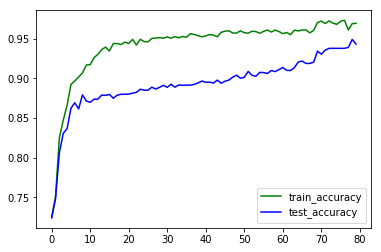

In [281]:
import matplotlib.pyplot as plt
import pandas as pd

result = pd.read_excel (r'/mnt/disks/user/project/results/cv_arousal/s32_2.xlsx', sheet_name="result")
print (result)
# gca stands for 'get current axis'
ax = plt.gca()
result.plot(kind='line',y='train_accuracy',color='green',ax=ax)
result.plot(kind='line',y='test_accuracy',color='blue',ax=ax)
plt.show()

### **`Calculate Accuracies`**

In [1]:
# -*- coding: utf-8 -*-
import xlrd
import xlwt
import argparse

In [2]:
out_book = xlwt.Workbook(encoding='utf-8', style_compression=0)
out_sheet = out_book.add_sheet('accuracy', cell_overwrite_ok=True)
column_index = 0
persons = 32
fold =3

In [3]:
def fill_heaer(column_index,model_name,target_class):
    # table header
    out_sheet.write(0,column_index,"model_name:")
    out_sheet.write(0,column_index+1,model_name)
    out_sheet.write(1,column_index,"target_class:")
    out_sheet.write(1,column_index+1,target_class)
    out_sheet.write(2,column_index,"subject")
    out_sheet.write(2,column_index+1,"accuracy")

In [4]:
def fill_cells(dir_path,column_index,model_name,target_class):
    fill_heaer(column_index,model_name,target_class)
    if target_class=="arousal":
        print("Acknowledgment Accuracy (%) Comparison for Each Subject on :",target_class)
    else:
        print("Acknowledgment Accuracy (%) Comparison for Each Subject on :",target_class)
    
    total_accuracy = 0
    for sub in range(1,persons+1):
        subject = "s%02d"%sub
        accuracy = 0
        for count in range(fold):
            input_file = dir_path+target_class+"/"+str(subject)+"_"+str(count)+".xlsx"
            in_book = xlrd.open_workbook(input_file)
            sheet = in_book.sheet_by_name("condition")
#             print(sheet.cell_value(1,8))
            accuracy = sheet.cell_value(1,8)
        accuracy2 = (accuracy/10)*100
        total_accuracy += accuracy2
        print(sub,":",accuracy)
        out_sheet.write(sub + 2,column_index, subject)
        out_sheet.write(sub + 2,column_index+1,accuracy)
    mean_accuracy = total_accuracy/persons
#     print("mean accuracy :",mean_accuracy)
    if target_class=="arousal":
        print("Acknowledgment mean Accuracy for all Subject on ",target_class,":",mean_accuracy)
    else:
        print("Acknowledgment mean Accuracy for all Subject on ",target_class,":",mean_accuracy)
    out_sheet.write(sub+3,column_index,"mean:")
    out_sheet.write(sub+3,column_index+1,mean_accuracy)

In [5]:
def fill_cells_origin(dir_path,column_index,model_name,target_class):
    # table header
    fill_heaer(column_index,model_name,target_class)
    total_accuracy = 0
    for sub in range(1,persons+1):
        subject = "s%02d"%sub
        accuracy = 0
        input_file = dir_path+target_class+"/"+str(subject)+".xlsx"
        in_book = xlrd.open_workbook(input_file)
        sheet = in_book.sheet_by_name("condition")
        accuracy += sheet.cell_value(1,8)
        accuracy = (accuracy)*100
        total_accuracy += accuracy
        print(sub,":",accuracy)
        out_sheet.write(sub + 2,column_index, subject)
        out_sheet.write(sub + 2,column_index+1,accuracy)
    mean_accuracy = total_accuracy/persons
    print("mean accuracy:",mean_accuracy)
    out_sheet.write(sub+3,column_index,"mean:")
    out_sheet.write(sub+3,column_index+1,mean_accuracy)

In [305]:
arousal_or_valence = "valence"
#fill_cells_origin("/mnt/disks/user/project/results/origin_",0,"without",arousal_or_valence)
fill_cells("/mnt/disks/user/project/results/cv_",3,"with",arousal_or_valence)
arousal_or_valence = "arousal"
#fill_cells_origin("/mnt/disks/user/project/results/origin_",6,"without",arousal_or_valence)
fill_cells("/mnt/disks/user/project/results/cv_",9,"with",arousal_or_valence)

out_book.save("accuracies.xls")

Acknowledgment Accuracy (%) Comparison for Each Subject on : valence
1 : 0.8801587422688802
2 : 0.7958333293596903
3 : 0.8791666825612386
4 : 0.83619047164917
5 : 0.841269850730896
6 : 0.8819444378217062
7 : 0.8742063442866007
8 : 0.8748015761375427
9 : 0.8267857035001119
10 : 0.8803571263949076
11 : 0.8067460258801779
12 : 0.8517857193946838
13 : 0.890357126394908
14 : 0.816746025880178
15 : 0.890357126394908
16 : 0.861785719394684
17 : 0.890357126394908
18 : 0.816746025880178
19 : 0.861785719394684
20 : 0.816746025880178
21 : 0.861785719394684
22 : 0.890357126394908
23 : 0.816746025880178
24 : 0.861785719394684
25 : 0.816746025880178
26 : 0.890357126394908
27 : 0.861785719394684
28 : 0.816746025880178
29 : 0.890357126394908
30 : 0.816746025880178
31 : 0.861785719394684
32 : 0.890357126394908
Acknowledgment mean Accuracy for all Subject on  valence : 8.546775747587285
Acknowledgment Accuracy (%) Comparison for Each Subject on : arousal
1 : 0.5515873034795126
2 : 0.8327380816141764
3 :